# A/B Тестирование
Полный анализ A/B теста с визуализацией и статистическими выводами

In [10]:
# Установка необходимых библиотек
!pip install pandas numpy scipy statsmodels plotly seaborn -q

## 1. Подготовка данных и EDA

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
from google.colab import files
import warnings
warnings.filterwarnings('ignore')

# Настройка стилей
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

In [12]:
# Чтение и очистка данных
df = pd.read_csv('marketing_AB.csv')
df.columns = df.columns.str.replace(' ', '_').str.lower()
df = df.drop_duplicates()
df = df.dropna()
print(f"\nДанные загружены: {len(df):,} записей")
print(f"\nПервые 5 строк:")
display(df.head())
print(f"\nИнформация о данных:")
df.info()


Данные загружены: 588,101 записей

Первые 5 строк:


,unnamed:_0,user_id,test_group,converted,total_ads,most_ads_day,most_ads_hour
0,0,1069124,ad,0,130,Monday,20
1,1,1119715,ad,0,93,Tuesday,22
2,2,1144181,ad,0,21,Tuesday,18
3,3,1435133,ad,0,355,Tuesday,10
4,4,1015700,ad,0,276,Friday,14



Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   unnamed:_0     588101 non-null  int64 
 1   user_id        588101 non-null  int64 
 2   test_group     588101 non-null  object
 3   converted      588101 non-null  int64 
 4   total_ads      588101 non-null  int64 
 5   most_ads_day   588101 non-null  object
 6   most_ads_hour  588101 non-null  int64 
dtypes: int64(5), object(2)
memory usage: 31.4+ MB


In [20]:
# Базовая статистика
print("\nБаланс групп:")
print(df['test_group'].value_counts())
print(f"\nПроцентное соотношение:")
print(df['test_group'].value_counts(normalize=True) * 100)

if 'converted' in df.columns:
    conversion_rate = df.groupby('test_group')['converted'].agg(['mean', 'sum', 'count'])
    conversion_rate.columns = ['Conversion_Rate', 'Total_Conversions', 'Total_Users']
    conversion_rate['Conversion_Rate'] = conversion_rate['Conversion_Rate'].map('{:.2%}'.format)
    display(conversion_rate)


Баланс групп:
test_group
ad     564577
psa     23524
Name: count, dtype: int64

Процентное соотношение:
test_group
ad     96.000007
psa     3.999993
Name: proportion, dtype: float64


,Conversion_Rate,Total_Conversions,Total_Users
test_group,,,
ad,2.55%,14423,564577
psa,1.79%,420,23524


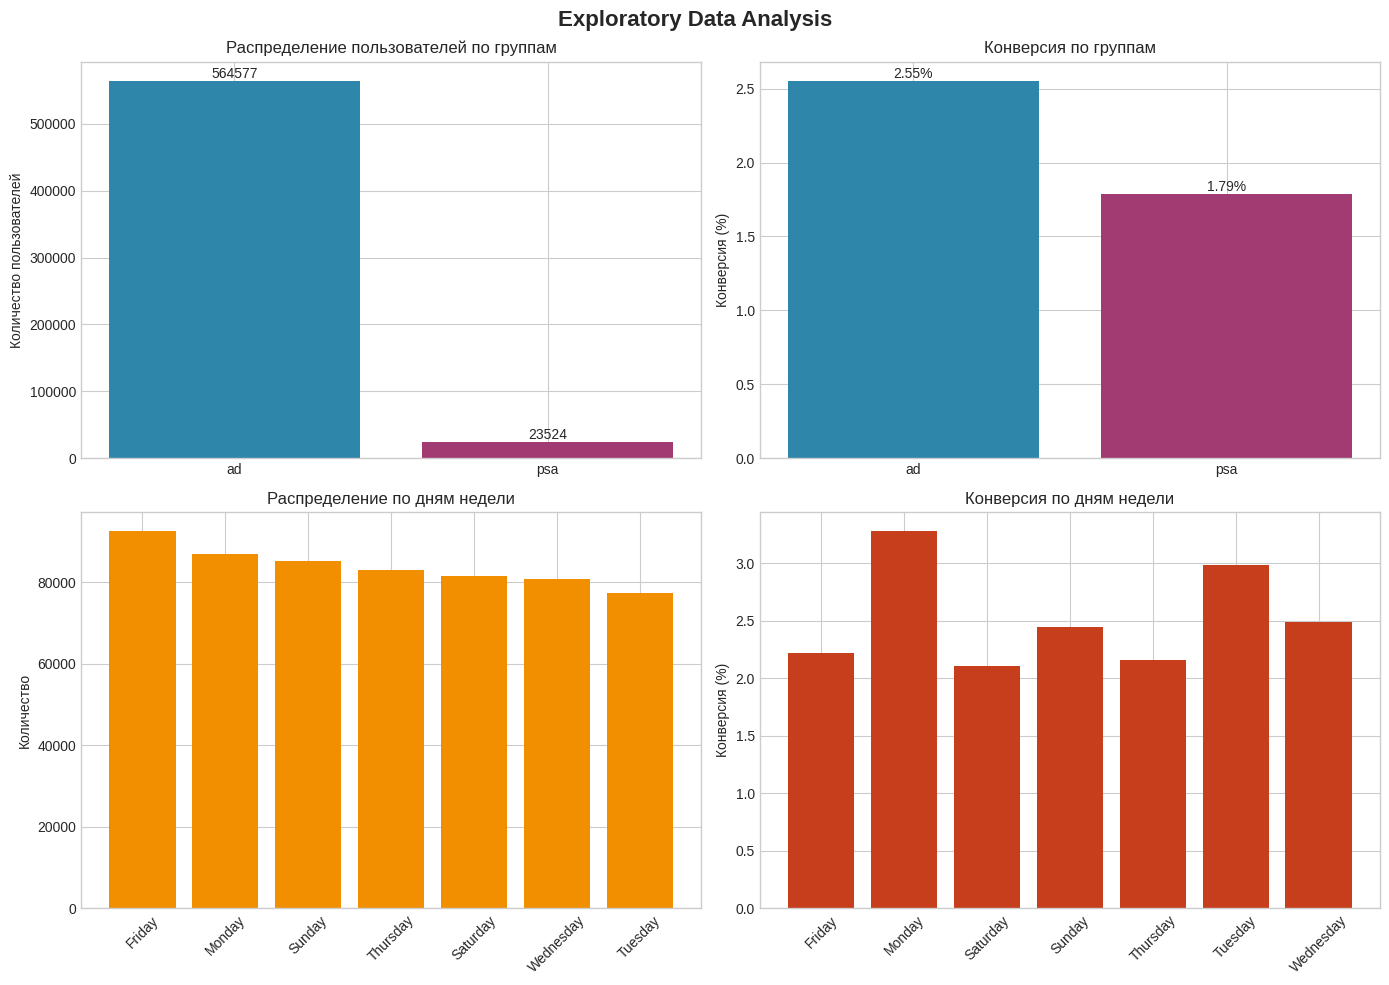

In [14]:
# Визуализация EDA
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Exploratory Data Analysis', fontsize=16, fontweight='bold')

# 1. Распределение пользователей по группам
group_counts = df['test_group'].value_counts()
axes[0, 0].bar(group_counts.index, group_counts.values, color=['#2E86AB', '#A23B72'])
axes[0, 0].set_title('Распределение пользователей по группам')
axes[0, 0].set_ylabel('Количество пользователей')
for i, v in enumerate(group_counts.values):
    axes[0, 0].text(i, v, str(v), ha='center', va='bottom')

# 2. Конверсия по группам
if 'converted' in df.columns:
    conv_by_group = df.groupby('test_group')['converted'].mean() * 100
    axes[0, 1].bar(conv_by_group.index, conv_by_group.values, color=['#2E86AB', '#A23B72'])
    axes[0, 1].set_title('Конверсия по группам')
    axes[0, 1].set_ylabel('Конверсия (%)')
    for i, v in enumerate(conv_by_group.values):
        axes[0, 1].text(i, v, f'{v:.2f}%', ha='center', va='bottom')

# 3. Распределение по дням недели
if 'most_ads_day' in df.columns:
    day_counts = df['most_ads_day'].value_counts()
    axes[1, 0].bar(day_counts.index, day_counts.values, color='#F18F01')
    axes[1, 0].set_title('Распределение по дням недели')
    axes[1, 0].set_ylabel('Количество')
    axes[1, 0].tick_params(axis='x', rotation=45)

# 4. Конверсия по дням недели
if 'converted' in df.columns and 'most_ads_day' in df.columns:
    conv_by_day = df.groupby('most_ads_day')['converted'].mean() * 100
    axes[1, 1].bar(conv_by_day.index, conv_by_day.values, color='#C73E1D')
    axes[1, 1].set_title('Конверсия по дням недели')
    axes[1, 1].set_ylabel('Конверсия (%)')
    axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 2. A/B Тестирование

In [27]:
def perform_ab_test(df, alpha=0.05):
    """
    Проведение A/B теста с полным статистическим анализом
    """

    # Группировка данных
    groups = df.groupby('test_group')['converted'].agg(['sum', 'count'])

    n_ad = groups.loc['ad', 'count']
    n_psa = groups.loc['psa', 'count']
    k_ad = groups.loc['ad', 'sum']
    k_psa = groups.loc['psa', 'sum']

    # Конверсии
    p_ad = k_ad / n_ad
    p_psa = k_psa / n_psa

    # Lift (прирост)
    lift = (p_ad - p_psa) / p_psa * 100 if p_psa > 0 else 0

    # Z-test
    z_stat, p_value = proportions_ztest([k_ad, k_psa], [n_ad, n_psa], alternative='two-sided')

    # Доверительный интервал для разницы пропорций
    diff = p_ad - p_psa
    se = np.sqrt(p_ad * (1 - p_ad) / n_ad + p_psa * (1 - p_psa) / n_psa)
    z_critical = stats.norm.ppf(1 - alpha / 2)
    ci_low = diff - z_critical * se
    ci_high = diff + z_critical * se

    # Доверительные интервалы для каждой группы
    ci_ad = proportion_confint(k_ad, n_ad, alpha=alpha, method='normal')
    ci_psa = proportion_confint(k_psa, n_psa, alpha=alpha, method='normal')

    # Мощность теста (post-hoc)
    p_pooled = (k_ad + k_psa) / (n_ad + n_psa)
    se_pool = np.sqrt(p_pooled * (1 - p_pooled) * (1/n_ad + 1/n_psa))
    effect_size = np.abs(p_ad - p_psa) / se_pool
    power = stats.norm.cdf(effect_size - z_critical)

    # Вывод результатов
    print(f"\n{'Метрика':<30} {'Ad':<15} {'PSA':<15}")
    print("-")
    print(f"{'Размер выборки':<30} {n_ad:<15,} {n_psa:<15,}")
    print(f"{'Конверсии':<30} {k_ad:<15,} {k_psa:<15,}")
    print(f"{'Конверсия (CR)':<30} {p_ad:<15.2%} {p_psa:<15.2%}")
    print(f"{'95% CI для CR':<30} [{ci_ad[0]:.4f}, {ci_ad[1]:.4f}]  [{ci_psa[0]:.4f}, {ci_psa[1]:.4f}]")

    print()
    print(f"{'Разница в конверсии':<40} {diff:.4f} ({diff:.2%})")
    print(f"{'Lift (прирост)':<40} {lift:+.2f}%")
    print(f"{'95% CI для разницы':<40} [{ci_low:.4f}, {ci_high:.4f}]")
    print(f"{'Z-статистика':<40} {z_stat:.4f}")
    print(f"{'P-value':<40} {p_value:.6f}")
    print(f"{'Мощность теста':<40} {power:.2%}")
    print(f"{'Уровень значимости (alpha)':<40} {alpha:.2f}")

    print(f"\n{'ВЫВОДЫ':<40}")
    print("-")

    if p_value < alpha:
        print(f"Статистически значимый результат (p-value < {alpha})")
        if lift > 0:
            print(f"Группа Ad показывает прирост конверсии на {lift:.2f}%")
        else:
            print(f"Группа PSA показывает лучшую конверсию на {abs(lift):.2f}%")
    else:
        print(f"Статистически незначимый результат (p-value >= {alpha})")
        print(f"Недостаточно доказательств для отклонения нулевой гипотезы")

    if power < 0.8:
        print(f"Низкая мощность теста ({power:.2%}). Рекомендуется увеличить выборку.")

    return {
        'n_ad': n_ad,
        'n_psa': n_psa,
        'k_ad': k_ad,
        'k_psa': k_psa,
        'p_ad': p_ad,
        'p_psa': p_psa,
        'lift': lift,
        'z_statistic': z_stat,
        'p_value': p_value,
        'ci_difference': (ci_low, ci_high),
        'ci_ad': ci_ad,
        'ci_psa': ci_psa,
        'power': power,
        'significant': p_value < alpha
    }

# Выполнение A/B теста
test_results = perform_ab_test(df)


Метрика                        Ad              PSA            
-
Размер выборки                 564,577         23,524         
Конверсии                      14,423          420            
Конверсия (CR)                 2.55%           1.79%          
95% CI для CR                  [0.0251, 0.0260]  [0.0162, 0.0195]

Разница в конверсии                      0.0077 (0.77%)
Lift (прирост)                           +43.09%
95% CI для разницы                       [0.0060, 0.0094]
Z-статистика                             7.3701
P-value                                  0.000000
Мощность теста                           100.00%
Уровень значимости (alpha)               0.05

ВЫВОДЫ                                  
-
Статистически значимый результат (p-value < 0.05)
Группа Ad показывает прирост конверсии на 43.09%


In [26]:
# Интерактивные визуализации
print("\nГенерация интерактивных графиков...")

# 1. Конверсия по группам с доверительными интервалами
fig1 = go.Figure()

fig1.add_trace(go.Bar(
    x=['Ad', 'PSA'],
    y=[test_results['p_ad'] * 100, test_results['p_psa'] * 100],
    error_y=dict(
        type='data',
        symmetric=False,
        array=[(test_results['ci_ad'][1] - test_results['p_ad']) * 100,
               (test_results['ci_psa'][1] - test_results['p_psa']) * 100],
        arrayminus=[(test_results['p_ad'] - test_results['ci_ad'][0]) * 100,
                    (test_results['p_psa'] - test_results['ci_psa'][0]) * 100],
        visible=True
    ),
    marker_color=['#2E86AB', '#A23B72'],
    name='Конверсия'
))

fig1.update_layout(
    title='Конверсия по группам с 95% доверительными интервалами',
    xaxis_title='Группа',
    yaxis_title='Конверсия (%)',
    height=500
)
fig1.show()

# 2. Распределение конверсии
if 'converted' in df.columns:
    fig2 = px.histogram(df, x='converted', color='test_group', barmode='overlay', opacity=0.7, title='Распределение конверсии по группам', labels={'converted': 'Конверсия', 'test_group': 'Группа'})
    fig2.update_layout(height=500)
    fig2.show()

# 3. Индикатор Lift
fig3 = go.Figure(go.Indicator(
    mode="number+delta",
    value=test_results['lift'],
    delta={'reference': 0, 'prefix': 'Lift: '},
    title={"text": "Прирост конверсии (Lift)"},
    number={'suffix': '%'}
))
fig3.update_layout(height=300)
fig3.show()


Генерация интерактивных графиков...


In [19]:
# Итоговая таблица результатов

summary_df = pd.DataFrame({
    'Группа': ['Ad', 'PSA'],
    'Размер выборки': [test_results['n_ad'], test_results['n_psa']],
    'Конверсии': [test_results['k_ad'], test_results['k_psa']],
    'Конверсия (%)': [f"{test_results['p_ad']:.2%}", f"{test_results['p_psa']:.2%}"],
    '95% CI': [f"[{test_results['ci_ad'][0]:.2%}, {test_results['ci_ad'][1]:.2%}]",
               f"[{test_results['ci_psa'][0]:.2%}, {test_results['ci_psa'][1]:.2%}]"]
})

display(summary_df)

stats_df = pd.DataFrame({
    'Показатель': ['Z-статистика', 'P-value', 'Lift',
                   '95% CI для разницы', 'Мощность теста', 'Статистическая значимость'],
    'Значение': [
        f"{test_results['z_statistic']:.4f}",
        f"{test_results['p_value']:.6f}",
        f"{test_results['lift']:+.2f}%",
        f"[{test_results['ci_difference'][0]:.4f}, {test_results['ci_difference'][1]:.4f}]",
        f"{test_results['power']:.2%}",
        "Да" if test_results['significant'] else "Нет"
    ]
})

display(stats_df)

,Группа,Размер выборки,Конверсии,Конверсия (%),95% CI
0,Ad,564577,14423,2.55%,"[2.51%, 2.60%]"
1,PSA,23524,420,1.79%,"[1.62%, 1.95%]"


,Показатель,Значение
0,Z-статистика,7.3701
1,P-value,0.000000
2,Lift,+43.09%
3,95% CI для разницы,"[0.0060, 0.0094]"
4,Мощность теста,100.00%
5,Статистическая значимость,Да
